In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
sns.set_theme(style="darkgrid")

In [2]:
data = pd.read_csv('/content/Gym_Progress_Dataset.csv')
data.head()
print(f'Is there any non numerical values ? : {data.isna().count().any()}')
print(f'Is there any duplicated rows ? : {data.duplicated().count().any()}')

Is there any non numerical values ? : True
Is there any duplicated rows ? : True


In [3]:
data.describe()

,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,69.878000,2703.915000,115.000000,66.555000,8352.705000
std,2.795656,466.300114,37.673952,29.866486,3701.129242
min,62.100000,1804.000000,50.000000,20.000000,2077.000000
25%,67.900000,2333.750000,82.750000,40.750000,5215.250000
50%,70.000000,2699.000000,114.500000,66.000000,8004.000000
75%,71.500000,3049.500000,148.000000,92.000000,11994.500000
max,78.200000,3498.000000,178.000000,119.000000,14999.000000


In [4]:
data.isna().sum()

,0
Day,0
Weight_kg,0
Calories_Intake,0
Protein_Intake_g,0
Workout_Duration_min,0
Steps_Walked,0


In [5]:
print(data.head())
data.dtypes

          Day  Weight_kg  Calories_Intake  Protein_Intake_g  \
0  2025-01-01       71.5             3209                70   
1  2025-01-02       69.6             2584               150   
2  2025-01-03       71.9             2927               148   
3  2025-01-04       74.6             3216                85   
4  2025-01-05       69.3             2045               145   

   Workout_Duration_min  Steps_Walked  
0                    41          6820  
1                    40          4898  
2                    89          9546  
3                    20          2077  
4                    24          9577  


,0
Day,object
Weight_kg,float64
Calories_Intake,int64
Protein_Intake_g,int64
Workout_Duration_min,int64
Steps_Walked,int64


<h2>changing Day to daytime<h2>


In [6]:
data['Day']=pd.to_datetime(data.Day)

<h1>DATA CLEANING<h1>
<h2>removing duplicates and non nummerical values <h2>

In [7]:
clean_data = data.dropna()
clean_data = data.drop_duplicates()

In [8]:
print(f'is there any calories intake above 5000 ? :{clean_data[clean_data.Calories_Intake > 5000].count().any()}')
print(f'is there any calories intake below 1000 ? :{clean_data[clean_data.Calories_Intake <1000].count().any()}')

is there any calories intake above 5000 ? :False
is there any calories intake below 1000 ? :False


<h2>Calculating Z-score <h2>

In [9]:
numeric_cols = ['Weight_kg', 'Calories_Intake',
                'Protein_Intake_g', 'Workout_Duration_min',
                'Steps_Walked']

z_scores = np.abs(
    (clean_data[numeric_cols] - clean_data[numeric_cols].mean())
    / clean_data[numeric_cols].std()
)
z_outliers = (z_scores > 3).any(axis=1)
clean_data[z_outliers]

,Day,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked


<h2>IQR</h2>

In [10]:
Q1  = clean_data[numeric_cols].quantile(0.25)
Q3  = clean_data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_outliers = (
    (clean_data[numeric_cols] < (Q1 - 1.5 * IQR)) |
    (clean_data[numeric_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)

clean_data[iqr_outliers]

,Day,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked
74,2025-03-16,62.1,2630,93,27,4371
113,2025-04-24,77.4,3108,167,111,7959
179,2025-06-29,78.2,1834,55,69,12395


<h2>Specific checks</h2>

In [11]:
clean_data['Weight_diff'] = clean_data['Weight_kg'].diff().abs()
big_jumps = clean_data[clean_data['Weight_diff'] > 3]
display(big_jumps[['Day', 'Weight_kg', 'Weight_diff']])

bad_cal = clean_data[
    (clean_data['Calories_Intake'] < 1000) |
    (clean_data['Calories_Intake'] > 5000)
]
display(bad_cal[['Day', 'Calories_Intake']])

,Day,Weight_kg,Weight_diff
4,2025-01-05,69.3,5.3
6,2025-01-07,74.7,5.4
8,2025-01-09,68.6,3.7
13,2025-01-14,64.3,6.4
15,2025-01-16,68.3,3.5
...,...,...,...
193,2025-07-13,66.3,4.3
194,2025-07-14,70.5,4.2
196,2025-07-16,67.3,3.9
197,2025-07-17,70.5,3.2


,Day,Calories_Intake


<h2>Boxplot</h2>

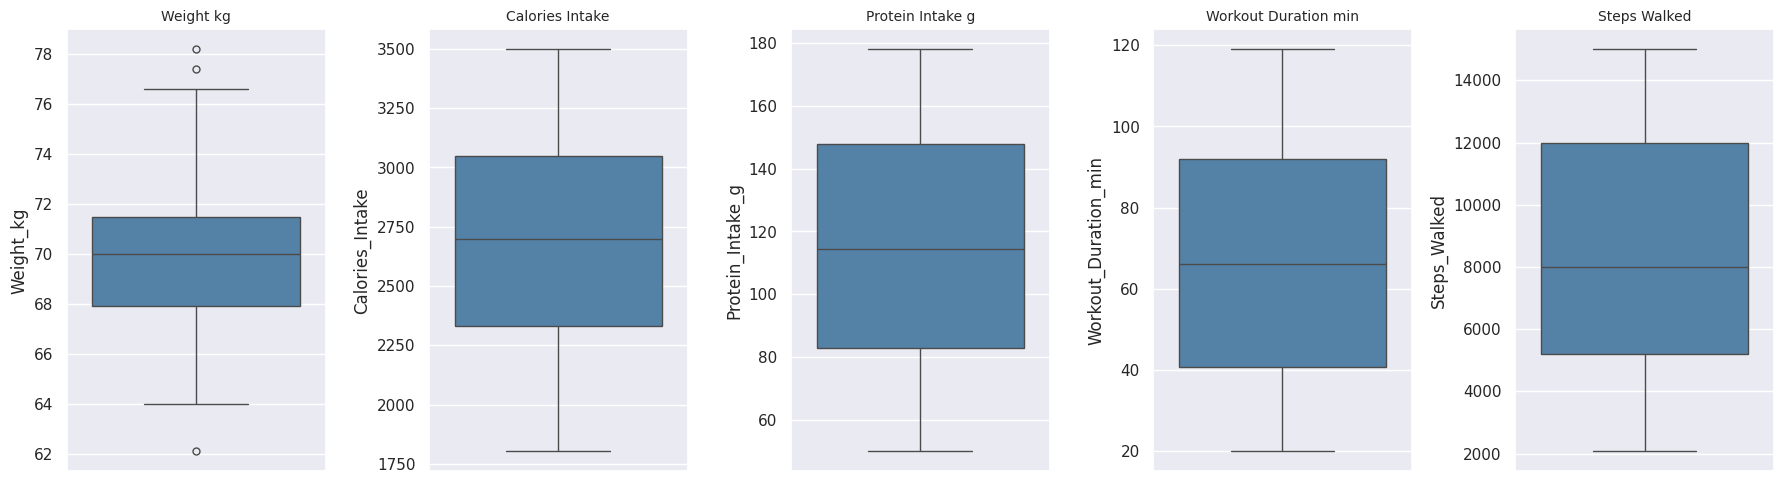

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=clean_data[col], ax=ax, color='steelblue',
                flierprops=dict(marker='o',
                                color='red',
                                markersize=5))
    ax.set_title(col.replace('_', ' '), fontsize=10)

plt.tight_layout()
plt.show()

<h2>Clip extreme values</h2>

In [13]:
shape_before = clean_data.shape
print("Before:", shape_before)
clean_data = clean_data[
    (clean_data['Weight_kg'] >= 50) &
    (clean_data['Weight_kg'] <= 150)
].reset_index(drop=True)

print("After drop:", clean_data.shape)

Before: (200, 7)
After drop: (200, 7)


In [14]:
# clip instead of dropping — keeps the day,
# just corrects the extreme value
clean_data['Calories_Intake'] = clean_data['Calories_Intake'].clip(
    lower=1000, upper=5000
)
clean_data['Protein_Intake_g'] = clean_data['Protein_Intake_g'].clip(
    lower=0, upper=400
)
clean_data['Workout_Duration_min'] = clean_data['Workout_Duration_min'].clip(
    lower=0, upper=300
)
clean_data['Steps_Walked'] = clean_data['Steps_Walked'].clip(
    lower=0, upper=40000
)

print("Clipping done")

Clipping done


<h2>EDA</h2>

<h2>Weight variation across Days</h2>

In [15]:
start_weight = clean_data['Weight_kg'].head(7).mean()
end_weight   = clean_data['Weight_kg'].tail(7).mean()
change       = end_weight - start_weight

print(f"Start avg (first 7 days): {start_weight:.2f} kg")
print(f"End avg   (last 7 days) : {end_weight:.2f} kg")
print(f"Net change              : {change:+.2f} kg")

Start avg (first 7 days): 71.56 kg
End avg   (last 7 days) : 68.94 kg
Net change              : -2.61 kg


<h2>correlation with weight loss</h2>

In [16]:
numeric_cols = ['Calories_Intake', 'Protein_Intake_g',
                'Workout_Duration_min', 'Steps_Walked']

correlations = clean_data[numeric_cols].corrwith(clean_data['Weight_kg'])
correlations = correlations.sort_values(key=abs, ascending=False)

print("Correlation with Weight_kg:")
print(correlations.round(3))

Correlation with Weight_kg:
Workout_Duration_min    0.053
Protein_Intake_g        0.037
Calories_Intake         0.024
Steps_Walked           -0.000
dtype: float64


<h2>calories and protein consistent</h2>

In [17]:
for col in ['Calories_Intake', 'Protein_Intake_g']:
    print(f"{col}")
    print(f"  mean : {clean_data[col].mean():.1f}")
    print(f"  std  : {clean_data[col].std():.1f}")
    print(f"  min  : {clean_data[col].min():.1f}")
    print(f"  max  : {clean_data[col].max():.1f}")


Calories_Intake
  mean : 2703.9
  std  : 466.3
  min  : 1804.0
  max  : 3498.0
Protein_Intake_g
  mean : 115.0
  std  : 37.7
  min  : 50.0
  max  : 178.0


<h2>What is my most common workout duration range?</h2>


In [18]:
bins   = [0, 30, 60, 90, 120, 300]
labels = ['0–30', '31–60', '61–90', '91–120', '120+']

clean_data['Duration_bucket'] = pd.cut(
    clean_data['Workout_Duration_min'],
    bins=bins, labels=labels
)

print(clean_data['Duration_bucket'].value_counts().sort_index())

Duration_bucket
0–30      31
31–60     60
61–90     57
91–120    52
120+       0
Name: count, dtype: int64


<h2>rest days</h2>

In [19]:
rest_days = clean_data.Day[clean_data.Workout_Duration_min == 0]
print(f"there is {rest_days.count()} rest days")

there is 0 rest days


<h2>correlation heatmap</h2>

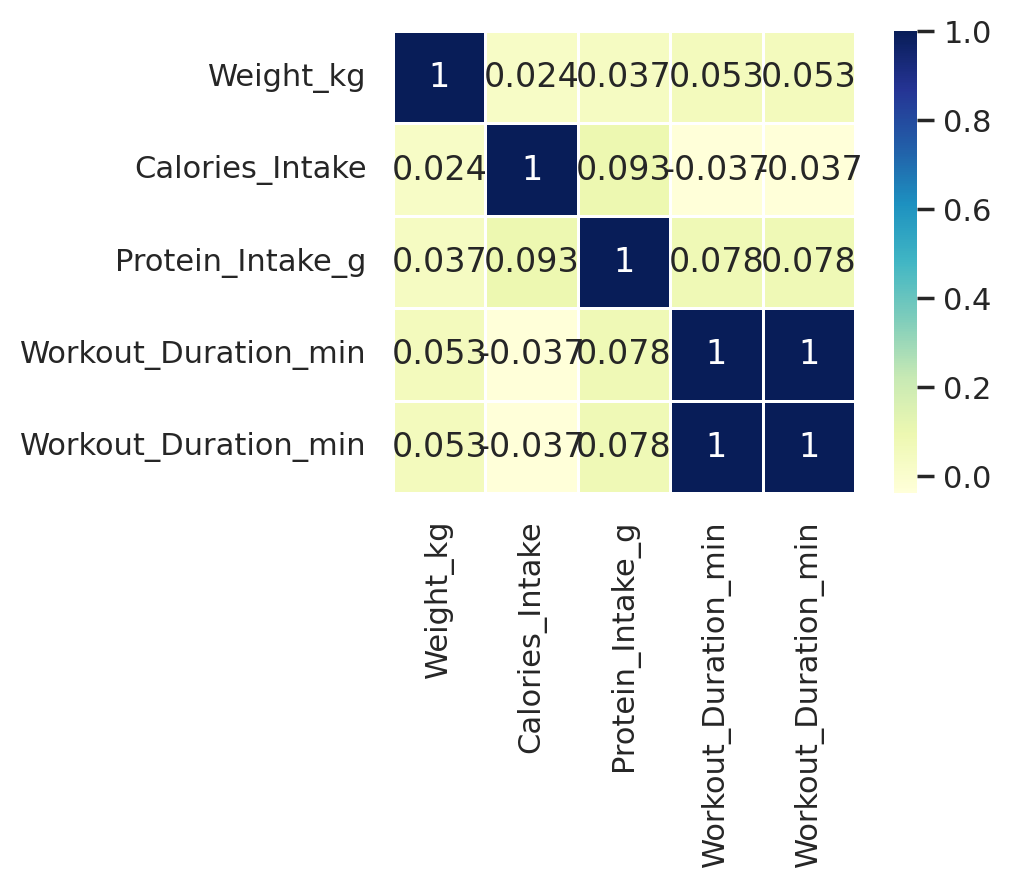

In [20]:
plt.figure(figsize = (5,3),dpi = 200)
numeric_cols_for_heatmap = ["Weight_kg",
                            "Calories_Intake",
                            "Protein_Intake_g",
                            "Workout_Duration_min",
                            "Workout_Duration_min"]
corrr_matrix = clean_data[numeric_cols_for_heatmap].corr()
sns.heatmap(corrr_matrix, annot=True, linewidths=.5, cmap="YlGnBu", square=True)
plt.show()

<h1>Data visualizations</h1>

<h2>Weight trend over 200 days </h2>

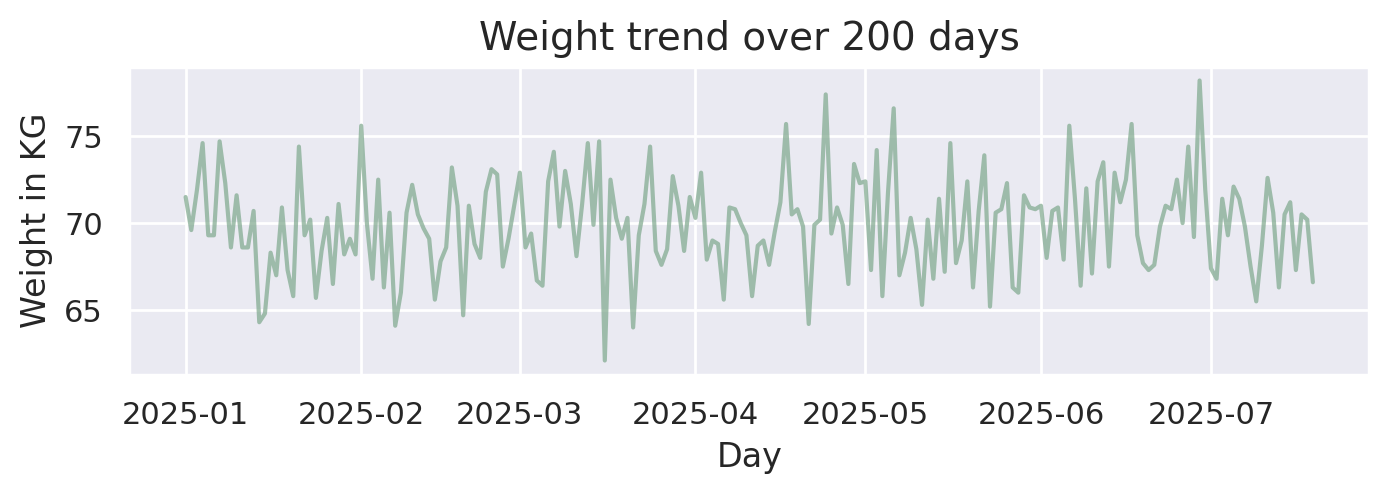

In [21]:
plt.figure (figsize=(8,2),dpi=200)
ax = plt.plot(clean_data['Day'], clean_data['Weight_kg'],
        color='#7DA78C', linewidth=1.5, alpha=0.7)
plt.title('Weight trend over 200 days',fontsize=14)
plt.xlabel('Day')
plt.ylabel('Weight in KG')
plt.show()


<h2>monthly average weight</h2>

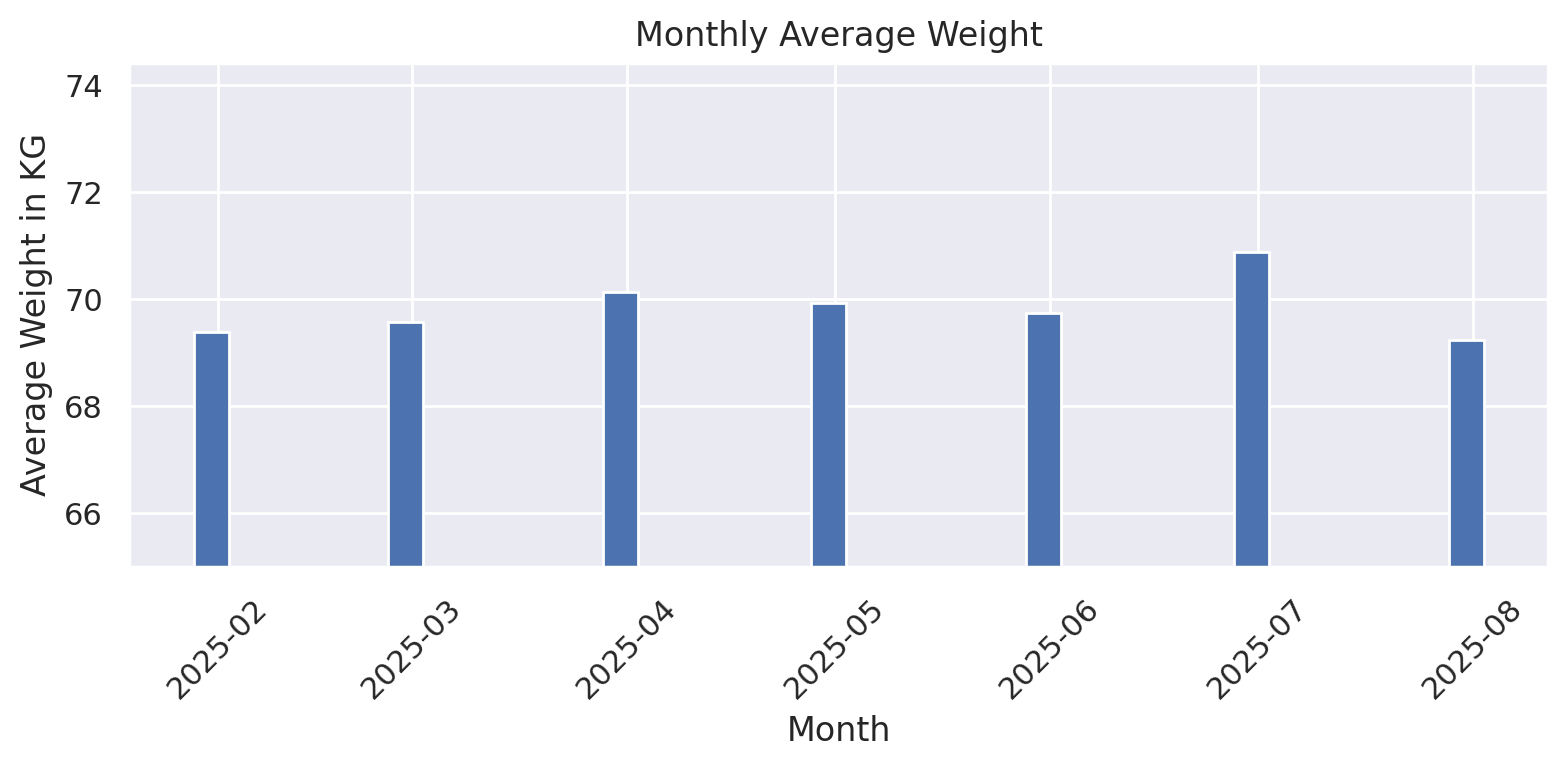

In [22]:
plt.figure(figsize=(8,4),dpi = 200)
monthly_weight = clean_data.set_index('Day')['Weight_kg'].resample('ME').mean()
plt.bar(monthly_weight.index, monthly_weight.values,width = 5)
plt.xlabel('Month')
plt.ylabel('Average Weight in KG')
plt.title('Monthly Average Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(65)
plt.show()

<h2> calories vs weight </h2>

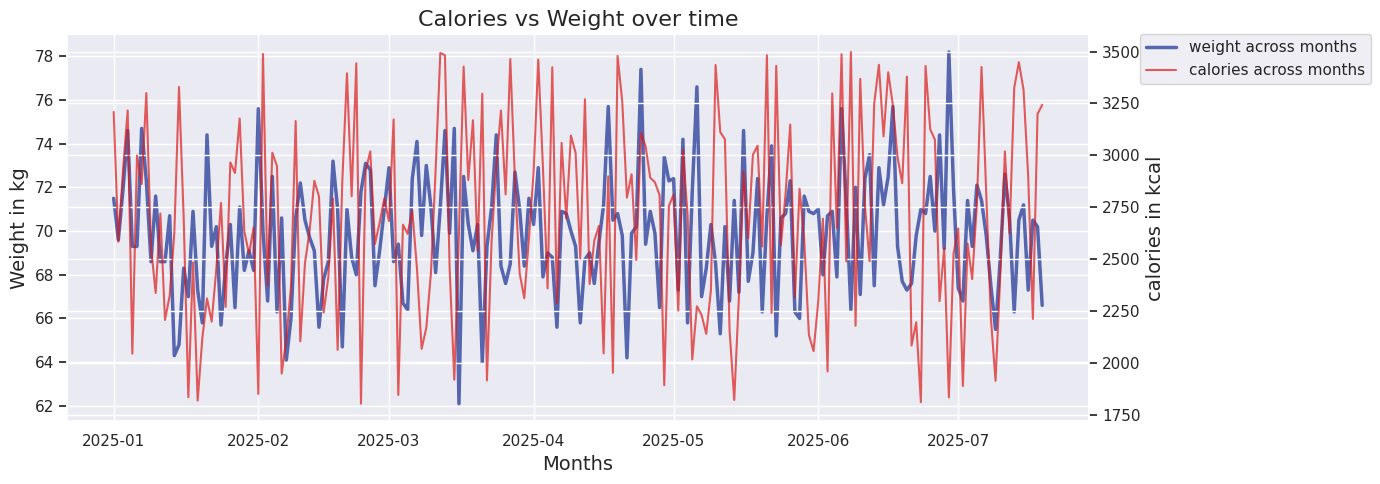

In [23]:
fig , axis1 = plt.subplots(figsize = (14,5))
axis1.plot(clean_data.Day,clean_data.Weight_kg,
                 alpha = 0.7,
                 linewidth = 2.5,
           color = '#162E93',
           label = 'weight across months')
axis2 = axis1.twinx()
axis2.plot(clean_data.Day,clean_data.Calories_Intake,
           alpha = 0.7,
           linewidth = 1.5,
           color = "#DB1A1A",
           label = 'calories across months')
axis1.set_xlabel('Months',fontsize=14)
axis2.set_xlabel('Months',fontsize=14)
axis1.set_ylabel('Weight in kg' , fontsize = 14)
axis2.set_ylabel('calories in kcal' , fontsize = 14)
axis1.set_title('Calories vs Weight over time',fontsize = 16)
lines1, labels1 = axis1.get_legend_handles_labels()
lines2, labels2 = axis2.get_legend_handles_labels()
axis1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
             bbox_to_anchor=(1.05, 1),
              borderaxespad=0)
plt.tight_layout()
plt.show()

<h2>Protein vs weigh</h2>

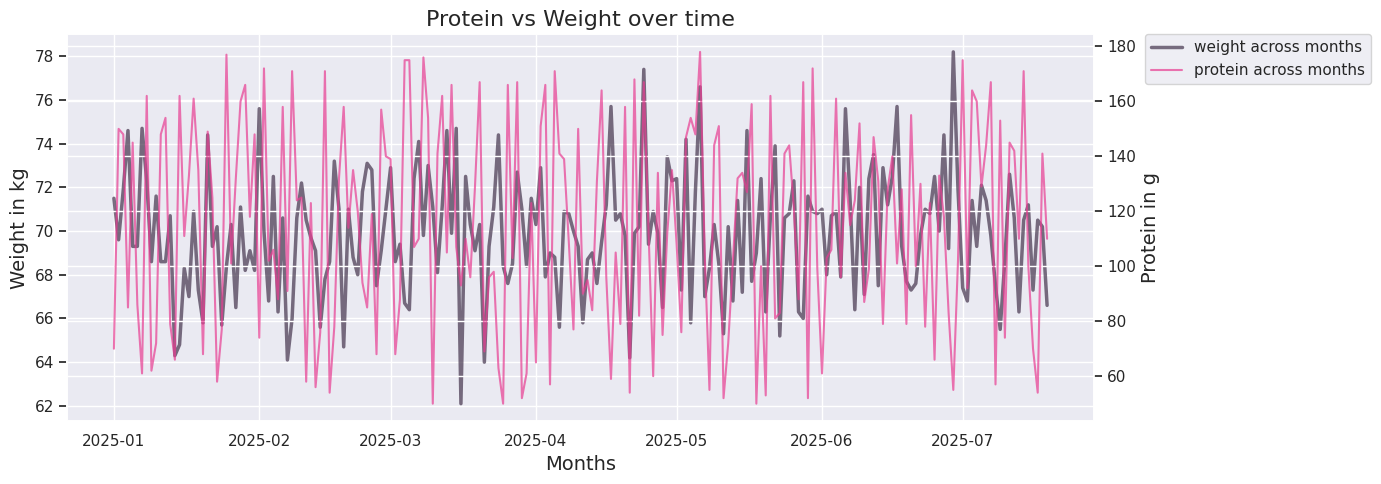

In [24]:
fig , axis1 = plt.subplots(figsize = (14,5))
axis1.plot(clean_data.Day,clean_data.Weight_kg,
                 alpha = 0.7,
                 linewidth = 2.5,
           color = '#43334C',
           label = 'weight across months')
axis2 = axis1.twinx()
axis2.plot(clean_data.Day,clean_data.Protein_Intake_g,
           alpha = 0.7,
           linewidth = 1.5,
           color = "#E83C91",
           label = 'protein across months')
axis1.set_xlabel('Months',fontsize=14)
axis2.set_xlabel('Months',fontsize=14)
axis1.set_ylabel('Weight in kg' , fontsize = 14)
axis2.set_ylabel('Protein in g' , fontsize = 14)
axis1.set_title('Protein vs Weight over time',fontsize = 16)
lines1, labels1 = axis1.get_legend_handles_labels()
lines2, labels2 = axis2.get_legend_handles_labels()
axis1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1),
    borderaxespad=0)
plt.tight_layout()
plt.show()

<h2>Workout distribution</h2>

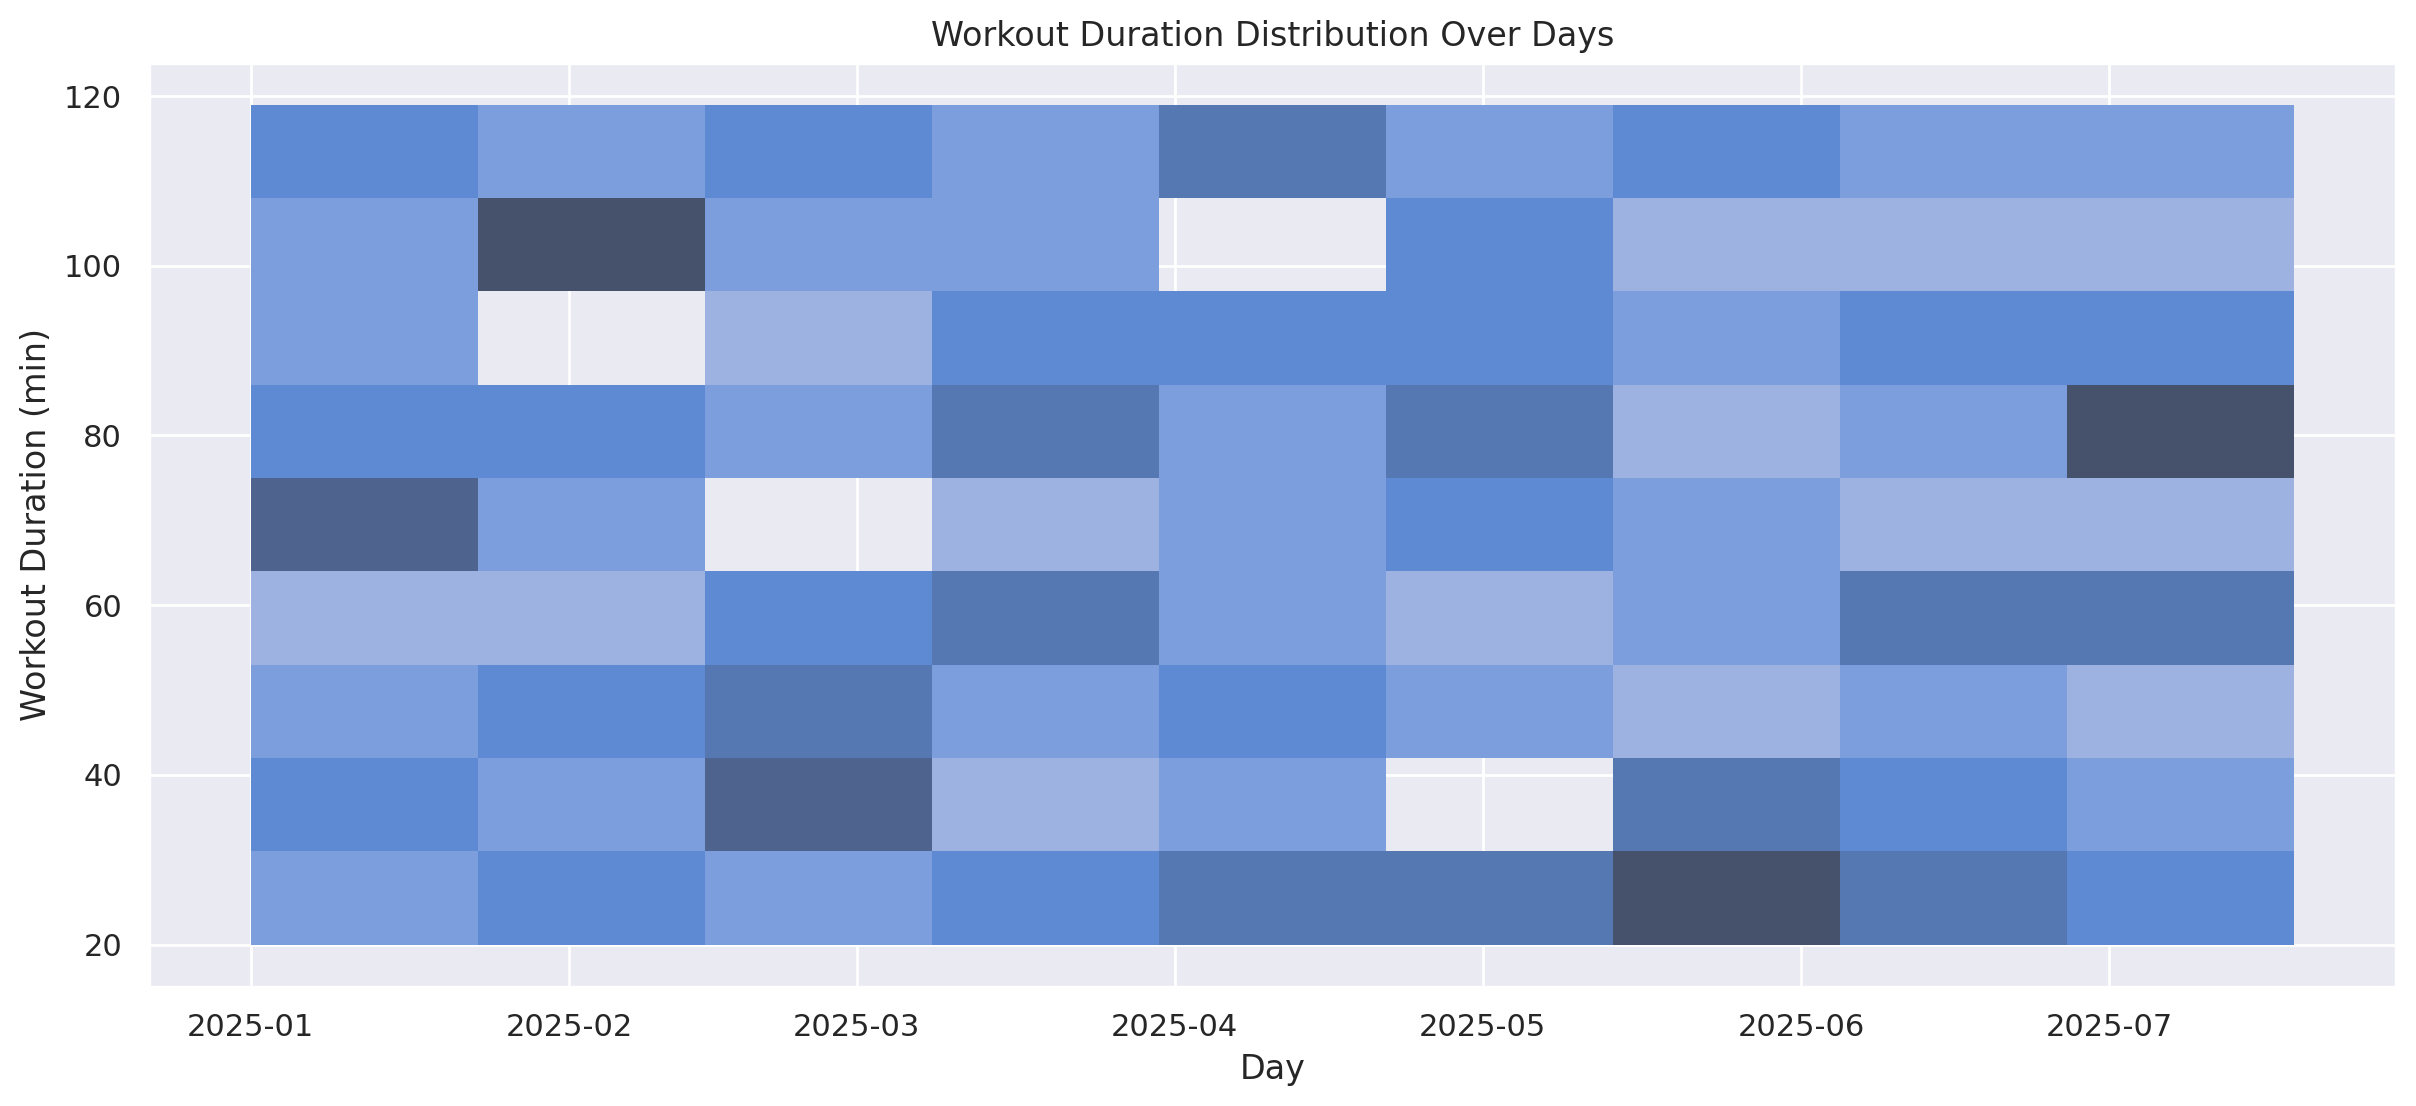

In [25]:
fig, ax = plt.subplots(figsize=(14.5, 6), dpi=200)
sns.histplot(clean_data, y='Workout_Duration_min', x='Day', ax=ax)
plt.title('Workout Duration Distribution Over Days')
plt.xlabel('Day')
plt.ylabel('Workout Duration (min)')
plt.show()

<h2>Monthly averages</h2>

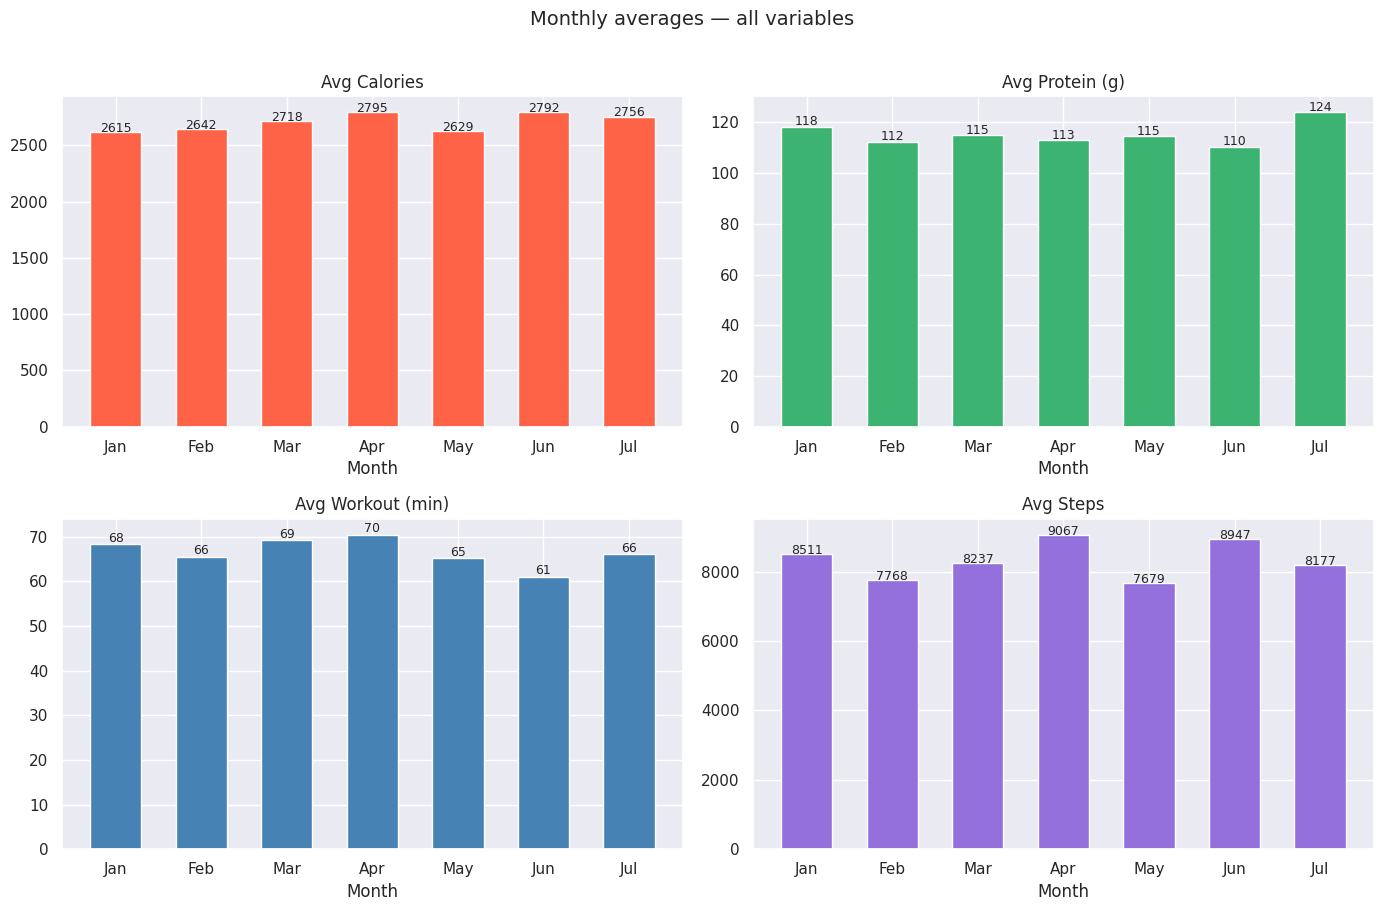

In [30]:
cols    = ['Calories_Intake', 'Protein_Intake_g',
           'Workout_Duration_min', 'Steps_Walked']
titles  = ['Avg Calories', 'Avg Protein (g)',
           'Avg Workout (min)', 'Avg Steps']
colors  = ['tomato', 'mediumseagreen', 'steelblue', 'mediumpurple']
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul']

monthly = clean_data.set_index('Day')[cols].resample('ME').mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col, title, color in zip(axes, cols, titles, colors):
    bars = ax.bar(months, monthly[col].values,
                  color=color, edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Month')
    for bar, val in zip(bars, monthly[col].values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', fontsize=9)

plt.suptitle('Monthly averages — all variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()